# Search Engine Demo Notebook

This notebook demonstrates the main functionalities of our search engine implementation.
It covers the complete pipeline from data generation to model training and ranking.

## Setup and Imports

In [1]:
import sys
import os

# Add project root to path so we can import our modules
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.search_engine import (
    make_template_db,
    make_search_logs,
    generate_features,
    train_ranking_model,
    rank_templates,
)

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("✓ All imports successful!")

✓ All imports successful!


## 1. Data Generation

First, let's generate our mock template database and search logs.

In [2]:
# Generate template database
template_db = make_template_db()
print(f"Generated {len(template_db)} templates\n")

# Display templates in a nice format
templates_df = pd.DataFrame(template_db)
print("Template Database:")
print("=" * 80)
for _, template in templates_df.iterrows():
    print(f"[{template['template_id']}] {template['title']}")
    print(f"    Description: {template['description']}")
    print(f"    Popularity: {template['popularity_score']}")
    print()

Generated 12 templates

Template Database:
[t001] Modern Business Card
    Description: Clean and professional business card design with minimalist layout
    Popularity: 4500

[t002] Creative Resume Template
    Description: Modern CV design with creative typography and clean sections
    Popularity: 3200

[t003] Wedding Invitation Card
    Description: Elegant wedding invitation with floral decorations and script fonts
    Popularity: 2800

[t004] Corporate Presentation Slides
    Description: Professional PowerPoint template for business presentations
    Popularity: 4100

[t005] Birthday Party Invite
    Description: Fun and colorful birthday invitation template for kids parties
    Popularity: 1900

[t006] Restaurant Menu Design
    Description: Modern restaurant menu layout with food photography sections
    Popularity: 2200

[t007] Social Media Post Template
    Description: Instagram post template with trendy graphics and text overlays
    Popularity: 3800

[t008] Professional 

In [3]:
# Generate search logs
search_logs = make_search_logs(template_db)
print(f"Generated {len(search_logs)} search interactions\n")

# Display search logs summary
logs_df = pd.DataFrame(search_logs)
print("Search Logs Summary:")
print("=" * 50)
print(f"Unique queries: {logs_df['query'].nunique()}")
print(f"Relevance score distribution:")
print(logs_df['relevance'].value_counts().sort_index())
print()

# Show sample logs by query
for query in logs_df['query'].unique():
    query_logs = logs_df[logs_df['query'] == query]
    print(f"\nQuery: '{query}'")
    for _, log in query_logs.iterrows():
        template = next(t for t in template_db if t['template_id'] == log['template_id'])
        print(f"  [{log['template_id']}] Relevance {log['relevance']} - {template['title']}")

Generated 25 search interactions

Search Logs Summary:
Unique queries: 5
Relevance score distribution:
relevance
0    10
1     5
2     5
3     5
Name: count, dtype: int64


Query: 'professional resume'
  [t002] Relevance 3 - Creative Resume Template
  [t008] Relevance 2 - Professional Portfolio
  [t001] Relevance 1 - Modern Business Card
  [t005] Relevance 0 - Birthday Party Invite
  [t009] Relevance 0 - Event Flyer Design

Query: 'birthday invite'
  [t005] Relevance 3 - Birthday Party Invite
  [t003] Relevance 2 - Wedding Invitation Card
  [t009] Relevance 1 - Event Flyer Design
  [t002] Relevance 0 - Creative Resume Template
  [t010] Relevance 0 - Annual Report Layout

Query: 'business card'
  [t001] Relevance 3 - Modern Business Card
  [t004] Relevance 2 - Corporate Presentation Slides
  [t008] Relevance 1 - Professional Portfolio
  [t006] Relevance 0 - Restaurant Menu Design
  [t007] Relevance 0 - Social Media Post Template

Query: 'social media post'
  [t007] Relevance 3 - Social 

## 2. Feature Generation

Now let's generate our hybrid features: BM25, embedding similarity, and popularity.

In [4]:
# Generate features
print("Generating features (this may take a moment to download the embedding model)...")
X, y, groups = generate_features(search_logs, template_db)

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector length: {len(y)}")
print(f"Groups for ranking: {groups}")
print(f"Total samples: {sum(groups)}")
print()

# Display feature statistics
print("Feature Statistics:")
print("=" * 50)
print(X.describe())

Generating features (this may take a moment to download the embedding model)...
Feature matrix shape: (25, 3)
Target vector length: 25
Groups for ranking: [5, 5, 5, 5, 5]
Total samples: 25

Feature Statistics:
       bm25_score  embedding_similarity  popularity_norm
count   25.000000             25.000000        25.000000
mean     1.094759              0.239192         0.497333
std      1.908956              0.222403         0.311198
min      0.000000             -0.011643         0.000000
25%      0.000000              0.085252         0.300000
50%      0.000000              0.162873         0.433333
75%      1.398077              0.396317         0.766667
max      6.599404              0.679866         1.000000


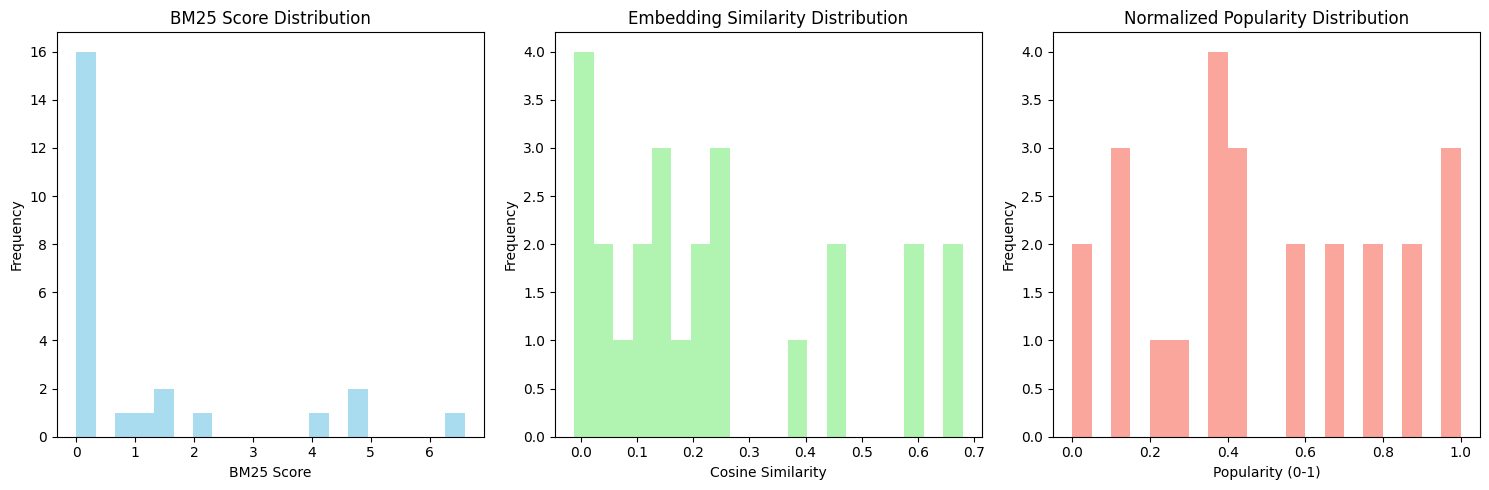

In [5]:
# Visualize feature distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# BM25 scores
axes[0].hist(X['bm25_score'], bins=20, alpha=0.7, color='skyblue')
axes[0].set_title('BM25 Score Distribution')
axes[0].set_xlabel('BM25 Score')
axes[0].set_ylabel('Frequency')

# Embedding similarities
axes[1].hist(X['embedding_similarity'], bins=20, alpha=0.7, color='lightgreen')
axes[1].set_title('Embedding Similarity Distribution')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Frequency')

# Popularity scores
axes[2].hist(X['popularity_norm'], bins=20, alpha=0.7, color='salmon')
axes[2].set_title('Normalized Popularity Distribution')
axes[2].set_xlabel('Popularity (0-1)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 3. Model Training

Train the XGBoost ranking model using our features.

In [6]:
# Train the model
print("Training XGBoost ranking model...")
model = train_ranking_model(X, y, groups)
print("✓ Model training completed!")
print(f"Model type: {type(model)}")

Training XGBoost ranking model...
✓ Model training completed!
Model type: <class 'xgboost.core.Booster'>


## 4. Template Ranking Demo

Test the ranking functionality with various queries.

In [7]:
def display_ranking_results(query, results, template_db, top_k=5):
    """Helper function to display ranking results nicely."""
    print(f"\n🔍 Query: '{query}'")
    print("=" * 60)
    
    if not results:
        print("No results found.")
        return
    
    for i, (template_id, score) in enumerate(results[:top_k], 1):
        template = next(t for t in template_db if t['template_id'] == template_id)
        print(f"{i:2d}. [{template_id}] Score: {score:6.3f}")
        print(f"    📄 {template['title']}")
        print(f"    📝 {template['description']}")
        print(f"    ⭐ Popularity: {template['popularity_score']}")
        print()

# Test queries
test_queries = [
    "professional resume",
    "cv template",
    "business card",
    "wedding invitation",
    "birthday party",
    "social media post",
    "logo design",
    "corporate presentation"
]

print("🚀 RANKING DEMONSTRATION")
print("=" * 80)

for query in test_queries:
    results = rank_templates(query, model, template_db, k=3)
    display_ranking_results(query, results, template_db, top_k=3)

🚀 RANKING DEMONSTRATION

🔍 Query: 'professional resume'
 1. [t002] Score:  1.804
    📄 Creative Resume Template
    📝 Modern CV design with creative typography and clean sections
    ⭐ Popularity: 3200

 2. [t008] Score:  0.649
    📄 Professional Portfolio
    📝 Clean portfolio website template for creative professionals
    ⭐ Popularity: 3500

 3. [t004] Score:  0.522
    📄 Corporate Presentation Slides
    📝 Professional PowerPoint template for business presentations
    ⭐ Popularity: 4100


🔍 Query: 'cv template'
 1. [t002] Score:  1.804
    📄 Creative Resume Template
    📝 Modern CV design with creative typography and clean sections
    ⭐ Popularity: 3200

 2. [t004] Score:  0.571
    📄 Corporate Presentation Slides
    📝 Professional PowerPoint template for business presentations
    ⭐ Popularity: 4100

 3. [t008] Score:  0.571
    📄 Professional Portfolio
    📝 Clean portfolio website template for creative professionals
    ⭐ Popularity: 3500


🔍 Query: 'business card'
 1. [t001]

In [20]:
display_ranking_results('food', rank_templates('food', model, template_db, k=5), template_db, top_k=5)


🔍 Query: 'food'
 1. [t006] Score:  1.650
    📄 Restaurant Menu Design
    📝 Modern restaurant menu layout with food photography sections
    ⭐ Popularity: 2200

 2. [t005] Score: -1.332
    📄 Birthday Party Invite
    📝 Fun and colorful birthday invitation template for kids parties
    ⭐ Popularity: 1900

 3. [t009] Score: -1.412
    📄 Event Flyer Design
    📝 Eye-catching flyer template for concerts and entertainment events
    ⭐ Popularity: 2600

 4. [t010] Score: -1.536
    📄 Annual Report Layout
    📝 Corporate annual report template with charts and data visualization
    ⭐ Popularity: 1500

 5. [t012] Score: -1.536
    📄 Newsletter Template
    📝 Email newsletter design with header, content sections and footer
    ⭐ Popularity: 2400



## 5. Interactive Query Testing

Try your own queries to see how the search engine performs.

In [8]:
# Interactive query testing
def test_custom_query(query, k=5):
    """Test a custom query and display results."""
    results = rank_templates(query, model, template_db, k=k)
    display_ranking_results(query, results, template_db, top_k=k)
    return results

# Example: Test your own query here!
# Uncomment and modify the line below:
# test_custom_query("your query here", k=3)

print("💡 TIP: Use test_custom_query('your query', k=3) to test your own queries!")

💡 TIP: Use test_custom_query('your query', k=3) to test your own queries!


## 6. Edge Case Testing

Test various edge cases to ensure robustness.

In [11]:
print("🧪 EDGE CASE TESTING")
print("=" * 80)

# Test empty query
print("\n1. Empty query:")
empty_results = rank_templates("", model, template_db, k=3)
print(f"Results for empty query: {len(empty_results)} items")

# Test k=0
print("\n2. k=0:")
zero_k_results = rank_templates("test", model, template_db, k=0)
print(f"Results for k=0: {len(zero_k_results)} items")

# Test very large k
print("\n3. Very large k:")
large_k_results = rank_templates("test", model, template_db, k=1000)
print(f"Results for k=1000: {len(large_k_results)} items (max: {len(template_db)})")

# Test semantic matching
print("\n4. Semantic matching test:")
print("Testing 'cv' vs 'resume' - should find similar results")
cv_results = rank_templates("cv", model, template_db, k=2)

resume_results = rank_templates("resume", model, template_db, k=2)

print(f"CV results: {[r[0] for r in cv_results]}")
print(f"Resume results: {[r[0] for r in resume_results]}")

print("\n✅ All edge case tests completed!")

🧪 EDGE CASE TESTING

1. Empty query:
Results for empty query: 3 items

2. k=0:
Results for k=0: 0 items

3. Very large k:
Results for k=1000: 12 items (max: 12)

4. Semantic matching test:
Testing 'cv' vs 'resume' - should find similar results
CV results: ['t002', 't008']
Resume results: ['t002', 't008']

✅ All edge case tests completed!


## 7. Summary and Conclusions

Summary of our search engine capabilities and performance.

In [10]:
print("📊 SEARCH ENGINE SUMMARY")
print("=" * 80)
print(f"📁 Templates in database: {len(template_db)}")
print(f"📝 Training samples: {len(search_logs)}")
print(f"🎯 Unique queries in training: {pd.DataFrame(search_logs)['query'].nunique()}")
print(f"🧮 Feature dimensions: {X.shape[1]}")

print("\n🚀 KEY FEATURES:")
print("  ✅ BM25 keyword matching")
print("  ✅ Semantic embedding similarity")
print("  ✅ Popularity-based ranking")
print("  ✅ XGBoost learning-to-rank")
print("  ✅ Edge case handling")
print("  ✅ Fast query processing")

print("\n🎯 DEMO COMPLETED SUCCESSFULLY!")
print("\nTo test your own queries, use:")
print("  results = rank_templates('your query here', model, template_db, k=5)")
print("  display_ranking_results('your query here', results, template_db)")

📊 SEARCH ENGINE SUMMARY
📁 Templates in database: 12
📝 Training samples: 25
🎯 Unique queries in training: 5
🧮 Feature dimensions: 3

🚀 KEY FEATURES:
  ✅ BM25 keyword matching
  ✅ Semantic embedding similarity
  ✅ Popularity-based ranking
  ✅ XGBoost learning-to-rank
  ✅ Edge case handling
  ✅ Fast query processing

🎯 DEMO COMPLETED SUCCESSFULLY!

To test your own queries, use:
  results = rank_templates('your query here', model, template_db, k=5)
  display_ranking_results('your query here', results, template_db)
